In [2]:
# ============================================
# CUSTOMER SEGMENTATION USING RFM & K-MEANS
# ============================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Date Handling
from datetime import timedelta

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
# Load dataset
df = pd.read_csv("Online_Retail_dataset.csv", encoding="ISO-8859-1")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
# First 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.00,United Kingdom


In [5]:
# Last 5 rows
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.00,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.00,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.00,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.00,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09-12-2011 12:50,4.95,12680.00,France


In [6]:
# Dataset dimensions
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 541909
Columns : 8


In [7]:
# Column names
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
# Statistical summary
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.00,541909,541909.00,406829.00,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,31-10-2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.55,NaN,4.61,15287.69,NaN
std,NaN,NaN,NaN,218.08,NaN,96.76,1713.60,NaN
min,NaN,NaN,NaN,-80995.00,NaN,-11062.06,12346.00,NaN
25%,NaN,NaN,NaN,1.00,NaN,1.25,13953.00,NaN
50%,NaN,NaN,NaN,3.00,NaN,2.08,15152.00,NaN
75%,NaN,NaN,NaN,10.00,NaN,4.13,16791.00,NaN


In [10]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)

missing

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [11]:
# Missing value percentage
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

CustomerID    24.93
Description    0.27
StockCode      0.00
InvoiceNo      0.00
Quantity       0.00
InvoiceDate    0.00
UnitPrice      0.00
Country        0.00
dtype: float64

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 5268


DATA CLEANING

In [13]:
# Create a copy of the original dataset
retail = df.copy()

In [14]:
print("Original Shape:", retail.shape)

Original Shape: (541909, 8)


In [15]:
retail = retail.dropna(subset=['CustomerID'])

print("Shape after removing missing CustomerID:", retail.shape)

Shape after removing missing CustomerID: (406829, 8)


In [16]:
retail = retail.drop_duplicates()

print("Shape after removing duplicates:", retail.shape)

Shape after removing duplicates: (401604, 8)


In [17]:
retail = retail[~retail['InvoiceNo'].astype(str).str.startswith('C')]

print("Shape after removing cancelled invoices:", retail.shape)

Shape after removing cancelled invoices: (392732, 8)


In [18]:
retail = retail[retail['Quantity'] > 0]

print("Shape after removing invalid quantities:", retail.shape)

Shape after removing invalid quantities: (392732, 8)


In [19]:
retail = retail[retail['UnitPrice'] > 0]

print("Shape after removing invalid prices:", retail.shape)

Shape after removing invalid prices: (392692, 8)


In [20]:
retail['InvoiceDate'] = pd.to_datetime(
    retail['InvoiceDate'],
    format='mixed',
    dayfirst=True
)

In [21]:
retail['InvoiceDate'].dtype

dtype('<M8[ns]')

In [22]:
retail['TotalAmount'] = retail['Quantity'] * retail['UnitPrice']

In [23]:
retail[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [24]:
print("Final Dataset Shape:", retail.shape)

retail.head()

Final Dataset Shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34


RFM Table

In [25]:
# Find the Latest Transaction Date

snapshot_date = retail['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


In [26]:
# Calculate RFM

rfm = retail.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [27]:
# Rename Columns

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [28]:
# View the RFM Table

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.00,326,1,77183.60
12347.00,2,7,4310.00
12348.00,75,4,1797.24
12349.00,19,1,1757.55
12350.00,310,1,334.40


In [29]:
print(rfm.shape)

(4338, 3)


In [30]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


Explore the RFM Data

In [31]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [32]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


In [33]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.00,92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,4338.00,4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,4338.00,2048.69,8985.23,3.75,306.48,668.57,1660.60,280206.02


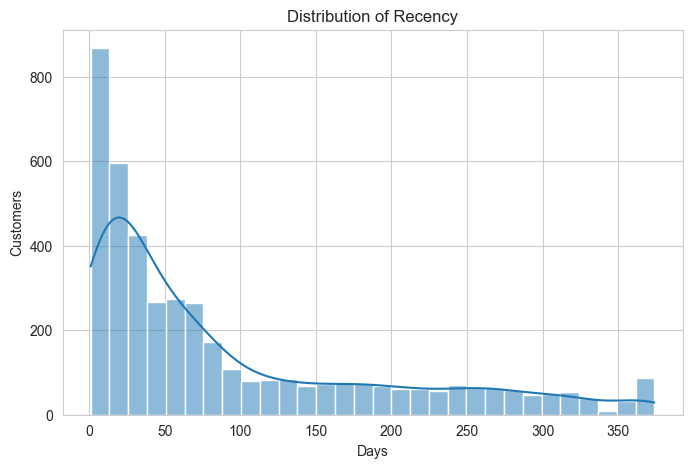

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title("Distribution of Recency")
plt.xlabel("Days")
plt.ylabel("Customers")
plt.show()

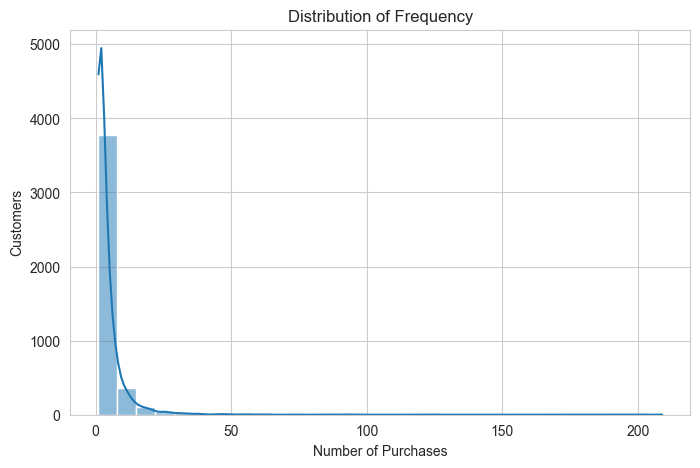

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title("Distribution of Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Customers")
plt.show()

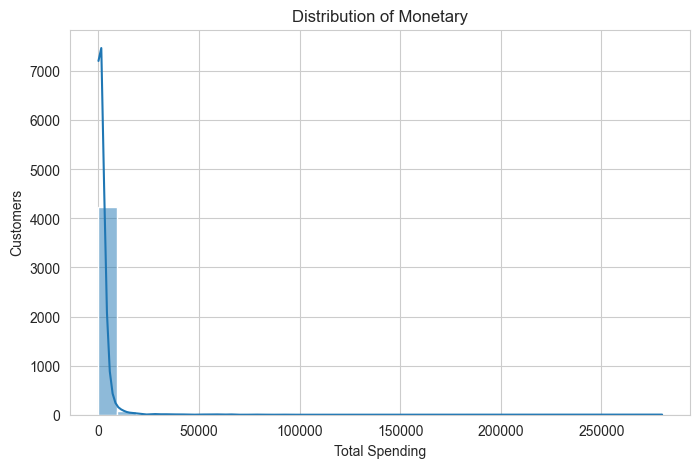

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title("Distribution of Monetary")
plt.xlabel("Total Spending")
plt.ylabel("Customers")
plt.show()

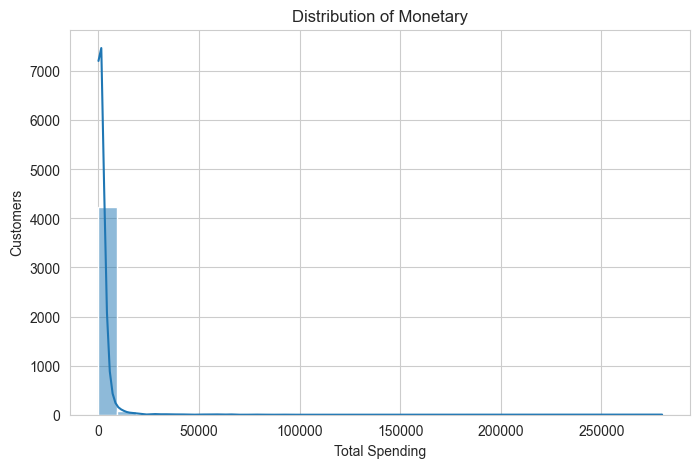

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title("Distribution of Monetary")
plt.xlabel("Total Spending")
plt.ylabel("Customers")
plt.show()

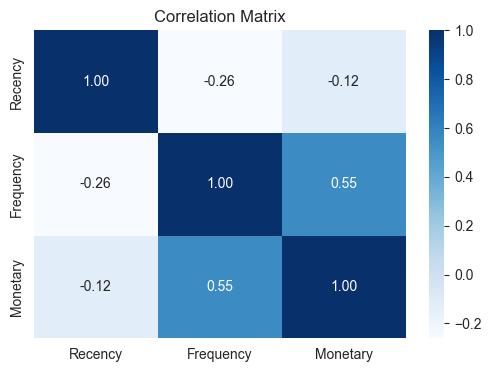

In [38]:
plt.figure(figsize=(6,4))
sns.heatmap(rfm.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Handle Outliers Using IQR

In [39]:
# Create a Function to Remove Outliers

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

In [40]:
print("Before Removing Outliers:", rfm.shape)

Before Removing Outliers: (4338, 3)


In [41]:
rfm_clean = rfm.copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_clean = remove_outliers(rfm_clean, col)

In [42]:
print("After Removing Outliers:", rfm_clean.shape)

After Removing Outliers: (3604, 3)


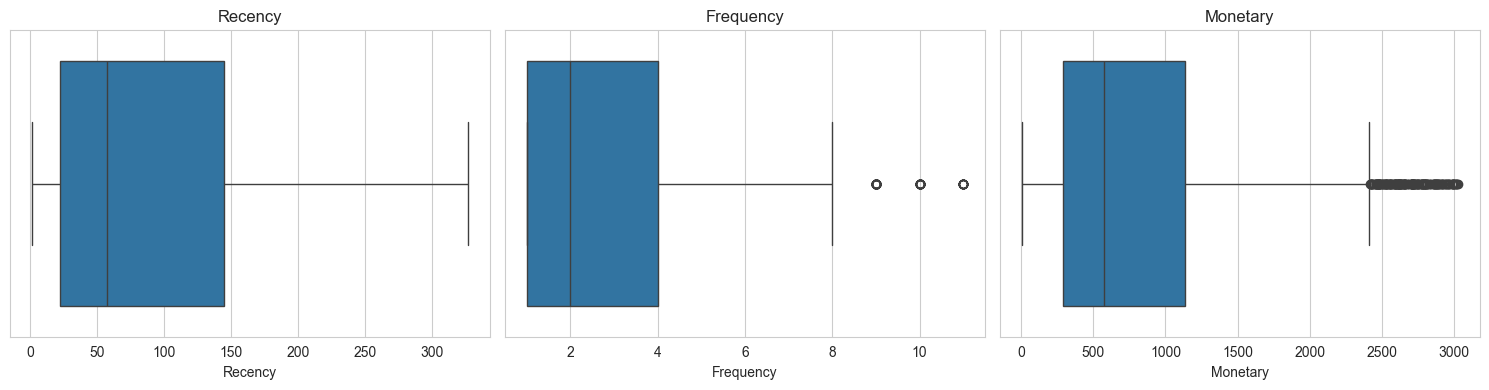

In [43]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(x=rfm_clean['Recency'])
plt.title("Recency")

plt.subplot(1,3,2)
sns.boxplot(x=rfm_clean['Frequency'])
plt.title("Frequency")

plt.subplot(1,3,3)
sns.boxplot(x=rfm_clean['Monetary'])
plt.title("Monetary")

plt.tight_layout()
plt.show()

Feature Scaling

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_clean)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_clean.columns,
    index=rfm_clean.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12348.00,-0.19,0.61,1.41
12349.00,-0.81,-0.83,1.35
12350.00,2.44,-0.83,-0.68
12352.00,-0.62,2.54,2.42
12353.00,1.26,-0.83,-1.03


In [45]:
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,3604.00,3604.00,3604.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.01,-0.83,-1.15
25%,-0.78,-0.83,-0.75
50%,-0.39,-0.35,-0.33
75%,0.59,0.61,0.47
max,2.63,3.98,3.17


Find the Optimal Number of Clusters (Elbow Method)

In [46]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

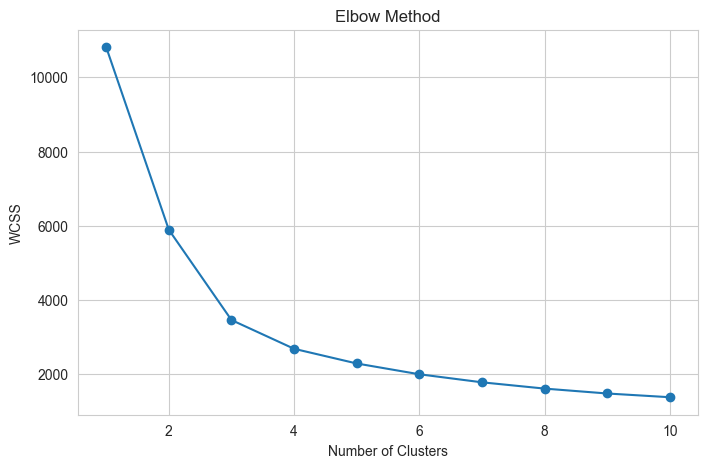

In [47]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [48]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.445
K = 3, Silhouette Score = 0.453
K = 4, Silhouette Score = 0.412
K = 5, Silhouette Score = 0.395
K = 6, Silhouette Score = 0.363
K = 7, Silhouette Score = 0.345
K = 8, Silhouette Score = 0.338
K = 9, Silhouette Score = 0.344
K = 10, Silhouette Score = 0.329


Train the Final K-Means Model

In [49]:
# Train K-Means with optimal K
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm_clean['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm_clean.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12348.00,75,4,1797.24,1
12349.00,19,1,1757.55,0
12350.00,310,1,334.40,2
12352.00,36,8,2506.04,1
12353.00,204,1,89.00,2


In [50]:
# Number of Customers in Each Cluster

rfm_clean['Cluster'].value_counts().sort_index()

Cluster
0    1879
1     819
2     906
Name: count, dtype: int64

In [51]:
cluster_summary = rfm_clean.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,49.56,2.03,556.25
1,37.18,5.69,1844.40
2,227.94,1.49,403.20


In [52]:
# Visualize the Clusters Using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = rfm_clean['Cluster'].values

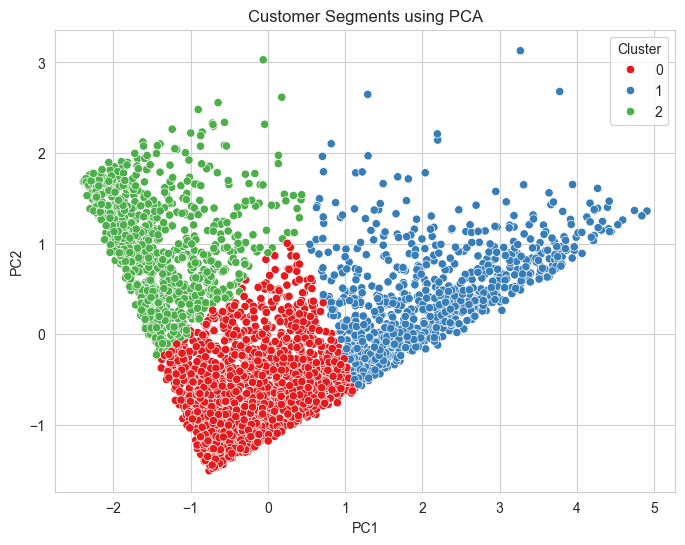

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segments using PCA")
plt.show()

Assign Business Labels

In [54]:
# Map cluster numbers to business names
cluster_names = {
    0: 'Regular Customers',
    1: 'Loyal Customers',
    2: 'At-Risk Customers'
}

rfm_clean['CustomerSegment'] = rfm_clean['Cluster'].map(cluster_names)

rfm_clean.head()

,Recency,Frequency,Monetary,Cluster,CustomerSegment
CustomerID,,,,,
12348.00,75,4,1797.24,1,Loyal Customers
12349.00,19,1,1757.55,0,Regular Customers
12350.00,310,1,334.40,2,At-Risk Customers
12352.00,36,8,2506.04,1,Loyal Customers
12353.00,204,1,89.00,2,At-Risk Customers


In [55]:
# Customer Count by Segment

segment_count = rfm_clean['CustomerSegment'].value_counts()

print(segment_count)

CustomerSegment
Regular Customers    1879
At-Risk Customers     906
Loyal Customers       819
Name: count, dtype: int64


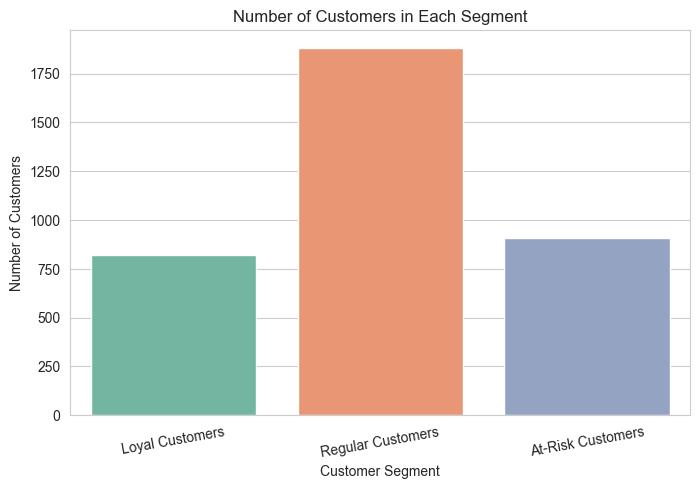

In [56]:
# Visualize Customer Segments

plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm_clean,
    x='CustomerSegment',
    hue='CustomerSegment',
    palette='Set2',
    legend=False
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=10)
plt.show()

Export for Power BI

In [57]:
rfm_clean.to_csv("Customer_Segments.csv", index=True)

print("Customer_Segments.csv exported successfully!")

Customer_Segments.csv exported successfully!


In [58]:
rfm_clean.head()

,Recency,Frequency,Monetary,Cluster,CustomerSegment
CustomerID,,,,,
12348.00,75,4,1797.24,1,Loyal Customers
12349.00,19,1,1757.55,0,Regular Customers
12350.00,310,1,334.40,2,At-Risk Customers
12352.00,36,8,2506.04,1,Loyal Customers
12353.00,204,1,89.00,2,At-Risk Customers


In [59]:
print("Rows in rfm_clean:", len(rfm_clean))
print("Unique customers:", rfm_clean.index.nunique())

Rows in rfm_clean: 3604
Unique customers: 3604


In [60]:
# Create PCA dataset for Power BI
pca_powerbi = rfm_clean.copy()

pca_powerbi['PC1'] = pca_df['PC1'].values
pca_powerbi['PC2'] = pca_df['PC2'].values

pca_powerbi.to_csv(
    "Customer_Segments_PowerBI.csv",
    index=True
)

print("Power BI dataset exported successfully!")
print(pca_powerbi.shape)

Power BI dataset exported successfully!
(3604, 7)
